In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [6]:
df = pd.read_parquet("../Data/Parquet/enhanced_summed_47photic.parquet", engine='pyarrow')

In [12]:
print(df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED',
       'CHL_A_SUMMED', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
       'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D',
       'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'K_PAR',
       'K_PAR_SLOPE'],
      dtype='object')


In [7]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ── Feature & target selection ──────────────────────────────────────────────
FEATURES = ['Lat_Dec', 'STA', 'DEPTH', 'CHL_A_SUMMED',
            'K_PAR', 'K_PAR_SLOPE', 'PAR', 'ESTCHL_STACORR']
TARGET   = 'Secchi'

df_model = df[FEATURES + [TARGET]].dropna()
print(f"Rows after dropping NaNs: {len(df_model)}")

X = df_model[FEATURES].values
y = df_model[TARGET].values


Rows after dropping NaNs: 1971


In [8]:
# ── Remove K_PAR / K_PAR_SLOPE rows beyond 3 std from the mean ───────────────
for col in ['K_PAR', 'K_PAR_SLOPE']:
    mean, std = df_model[col].mean(), df_model[col].std()
    lo, hi = mean - 3 * std, mean + 3 * std
    n_before = len(df_model)
    df_model = df_model[df_model[col].between(lo, hi)]
    print(f"{col}: mean={mean:.4f}  std={std:.4f}  "
          f"bounds=[{lo:.4f}, {hi:.4f}]  "
          f"removed {n_before - len(df_model)} rows")

print(f"\nRows after outlier filtering: {len(df_model)}")

# Redefine X / y from the filtered frame
X = df_model[FEATURES].values
y = df_model[TARGET].values

K_PAR: mean=0.1285  std=0.3368  bounds=[-0.8819, 1.1389]  removed 8 rows
K_PAR_SLOPE: mean=0.1141  std=0.1278  bounds=[-0.2692, 0.4974]  removed 31 rows

Rows after outlier filtering: 1932


In [9]:
# ── 80/20 Train / Test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ── Standardise features (fit on train only) ─────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


Train size: 1545  |  Test size: 387


In [10]:
# ── LASSO with 5-fold CV to select optimal alpha ─────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = np.logspace(-4, 2, 200)          # search grid: 0.0001 → 100

lasso_cv = LassoCV(
    alphas=alphas,
    cv=kf,
    max_iter=10_000,
    random_state=42
)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
print(f"Best alpha (λ): {best_alpha:.6f}")
print(f"CV MSE path shape (alphas × folds): {lasso_cv.mse_path_.shape}")


Best alpha (λ): 0.000567
CV MSE path shape (alphas × folds): (200, 5)


In [11]:
# ── Evaluate on held-out test set ────────────────────────────────────────────
y_pred = lasso_cv.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("── Test-set performance ──────────────────────────────")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# ── Coefficients table ────────────────────────────────────────────────────────
coef_df = (
    pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso_cv.coef_})
    .reindex(pd.Series(np.abs(lasso_cv.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n── Feature coefficients (sorted by |coef|) ───────────")
print(coef_df.to_string(index=False))


── Test-set performance ──────────────────────────────
  RMSE : 5.6310
  R²   : 0.5885

── Feature coefficients (sorted by |coef|) ───────────
       Feature  Coefficient
         DEPTH     4.632746
         K_PAR     4.061851
   K_PAR_SLOPE    -3.988235
       Lat_Dec    -1.634986
  CHL_A_SUMMED    -1.514281
           STA     1.040577
           PAR     0.553860
ESTCHL_STACORR     0.144161


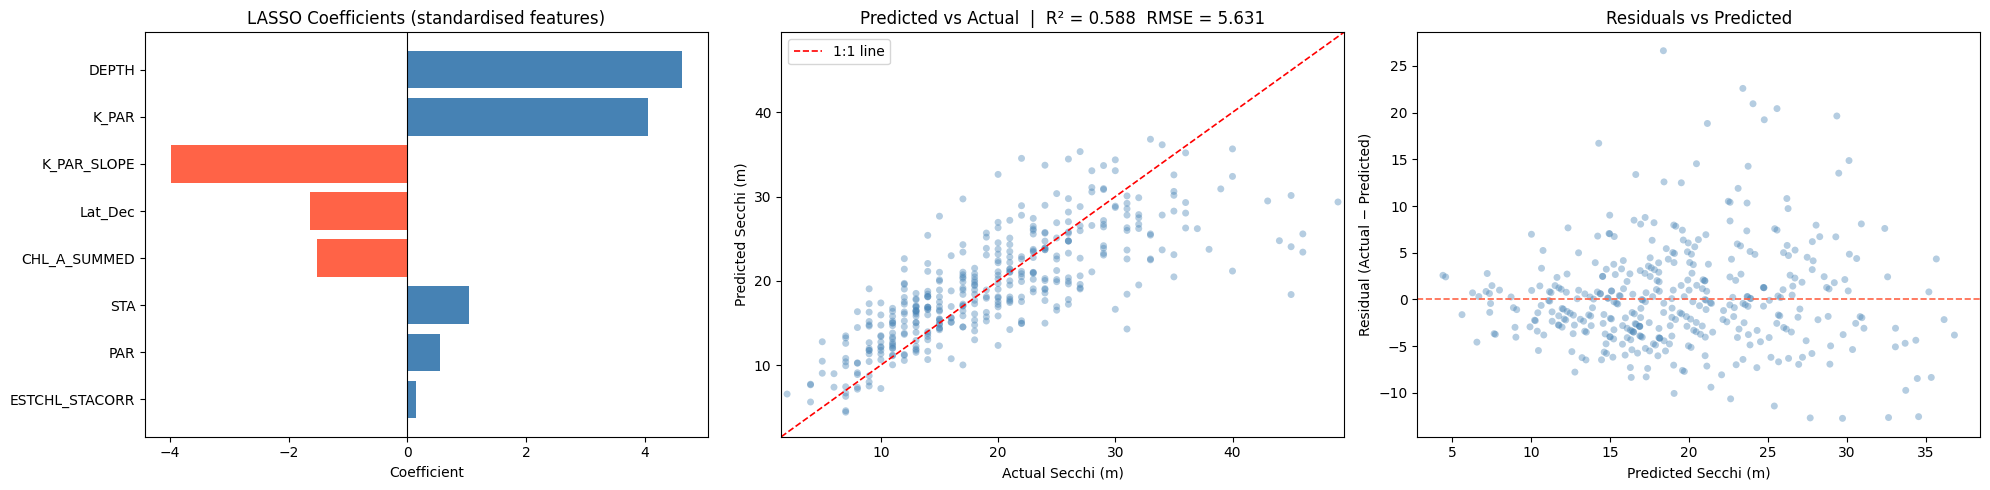

In [12]:
# ── Visualisations ────────────────────────────────────────────────────────────
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Coefficient bar chart
ax = axes[0]
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LASSO Coefficients (standardised features)')
ax.invert_yaxis()

# 2. Predicted vs Actual
ax = axes[1]
lims = [min(y_test.min(), y_pred.min()) - 0.5,
        max(y_test.max(), y_pred.max()) + 0.5]
ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Secchi (m)')
ax.set_ylabel('Predicted Secchi (m)')
ax.set_title(f'Predicted vs Actual  |  R² = {r2:.3f}  RMSE = {rmse:.3f}')
ax.legend()

# 3. Residuals vs Predicted
ax = axes[2]
ax.scatter(y_pred, residuals, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.axhline(0, color='tomato', linestyle='--', linewidth=1.2)
ax.set_xlabel('Predicted Secchi (m)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


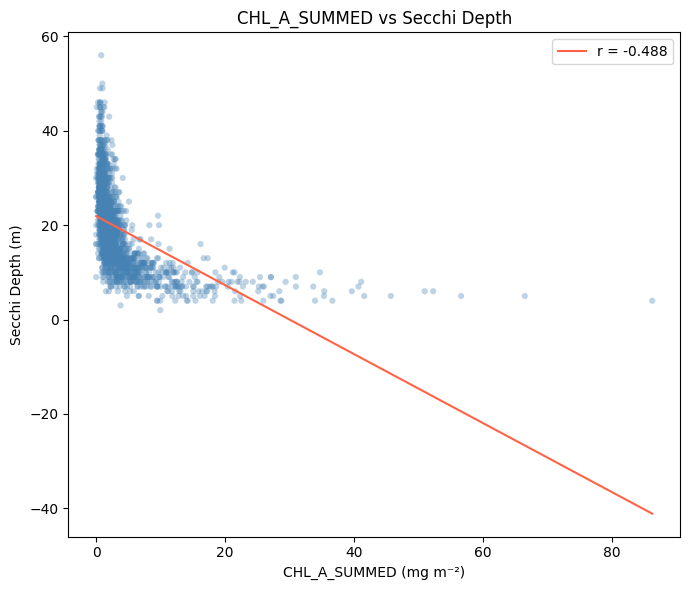

In [ ]:
# ── CHL_A_SUMMED vs Secchi correlation scatterplot ───────────────────────────
r = df_model['CHL_A_SUMMED'].corr(df_model['Secchi'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_model['CHL_A_SUMMED'], df_model['Secchi'],
           alpha=0.35, edgecolors='none', color='steelblue', s=20)

# linear trend line
m, b = np.polyfit(df_model['CHL_A_SUMMED'], df_model['Secchi'], 1)
x_line = np.linspace(df_model['CHL_A_SUMMED'].min(), df_model['CHL_A_SUMMED'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, label=f'r = {r:.3f}')

ax.set_xlabel('CHL_A_SUMMED (mg m⁻²)')
ax.set_ylabel('Secchi Depth (m)')
ax.set_title('CHL_A_SUMMED vs Secchi Depth')
ax.legend()
plt.tight_layout()
plt.show()

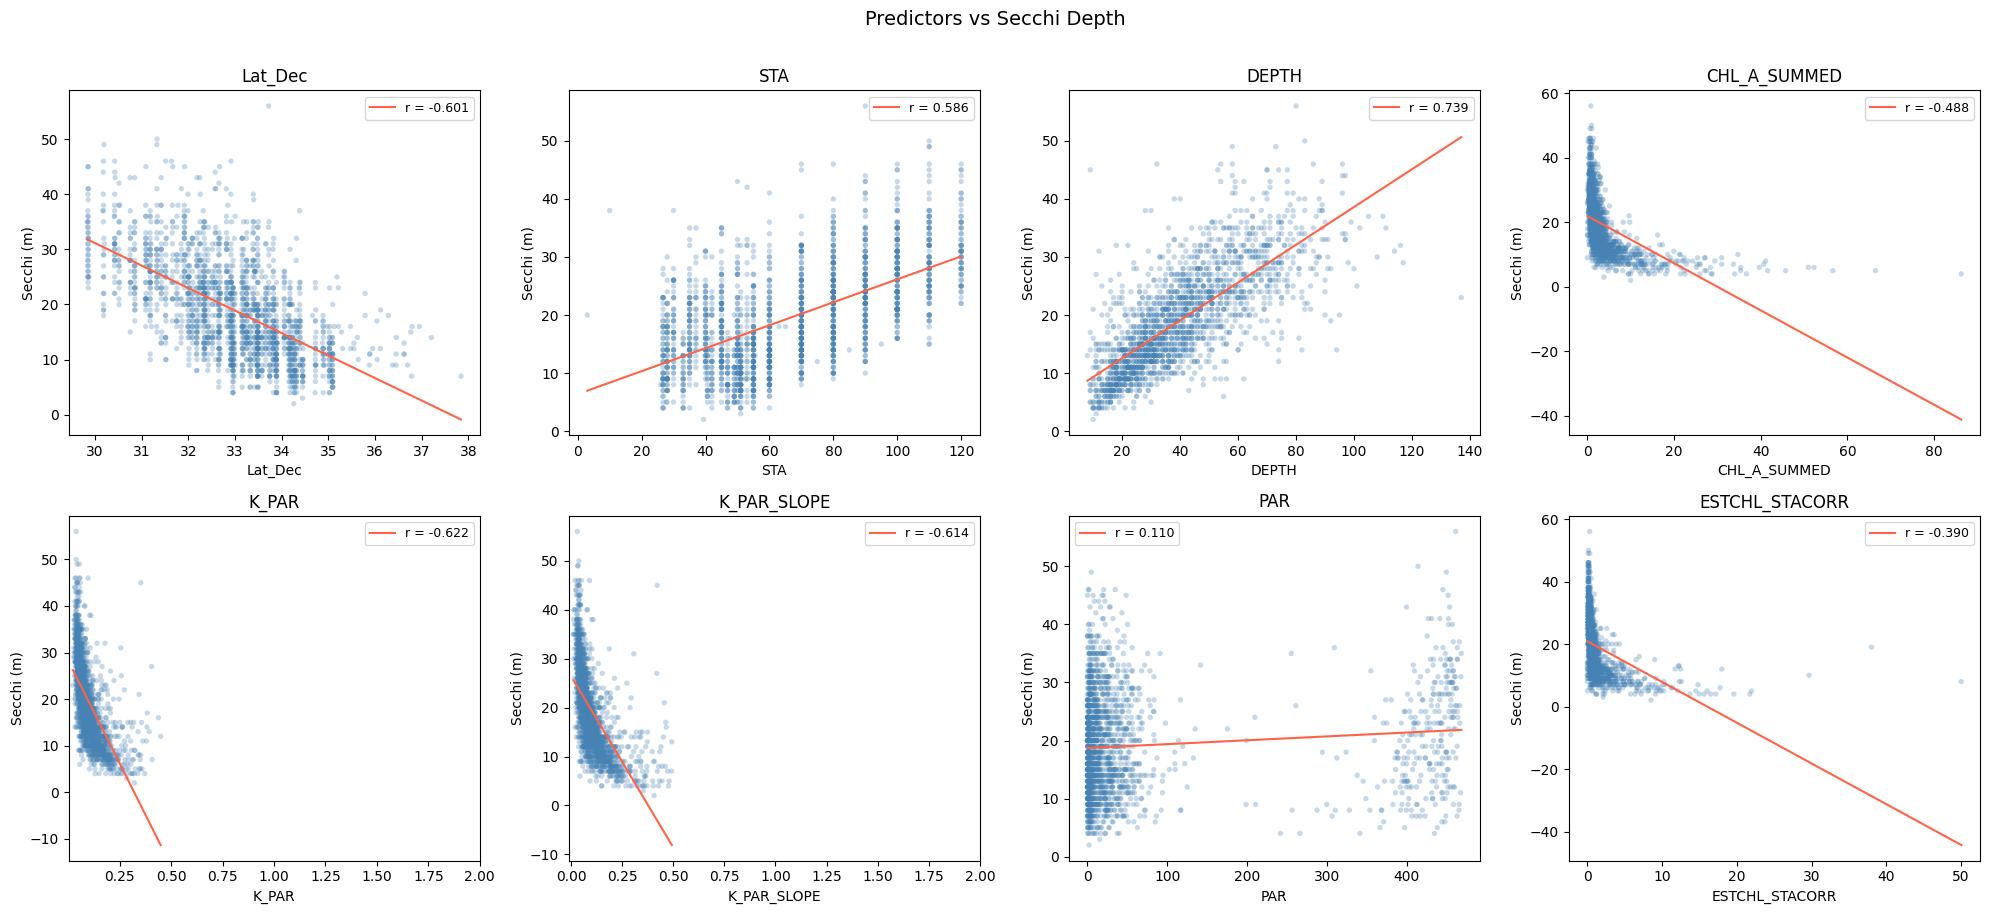

In [46]:
# ── All predictors vs Secchi ──────────────────────────────────────────────────
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9))
axes = axes.flatten()

X_RANGE_OVERRIDES = {'K_PAR': 2, 'K_PAR_SLOPE': 2}

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    r = df_model[feature].corr(df_model['Secchi'])

    ax.scatter(df_model[feature], df_model['Secchi'],
               alpha=0.3, edgecolors='none', color='steelblue', s=15)

    m, b = np.polyfit(df_model[feature], df_model['Secchi'], 1)
    x_line = np.linspace(df_model[feature].min(), df_model[feature].max(), 200)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, label=f'r = {r:.3f}')

    ax.set_xlabel(feature)
    ax.set_ylabel('Secchi (m)')
    ax.set_title(feature)
    ax.legend(fontsize=9)

    if feature in X_RANGE_OVERRIDES:
        ax.set_xlim(right=X_RANGE_OVERRIDES[feature])

# hide any unused axes
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predictors vs Secchi Depth', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [47]:
# ── Refit: log-transform CHL_A_SUMMED and ESTCHL_STACORR ─────────────────────
df_log = df_model.copy()
df_log['LOG_CHL_A_SUMMED']   = np.log1p(df_log['CHL_A_SUMMED'])
df_log['LOG_ESTCHL_STACORR'] = np.log1p(df_log['ESTCHL_STACORR'])

FEATURES_LOG = ['Lat_Dec', 'STA', 'DEPTH', 'LOG_CHL_A_SUMMED',
                'K_PAR', 'K_PAR_SLOPE', 'PAR', 'LOG_ESTCHL_STACORR']

X_log = df_log[FEATURES_LOG].values
y_log = df_log[TARGET].values

# 80/20 split (same random state for fair comparison)
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.20, random_state=42
)

scaler_log   = StandardScaler()
X_log_train  = scaler_log.fit_transform(X_log_train)
X_log_test   = scaler_log.transform(X_log_test)

# 5-fold LassoCV
lasso_log = LassoCV(alphas=alphas, cv=kf, max_iter=10_000, random_state=42)
lasso_log.fit(X_log_train, y_log_train)

y_log_pred  = lasso_log.predict(X_log_test)
rmse_log    = np.sqrt(mean_squared_error(y_log_test, y_log_pred))
r2_log      = r2_score(y_log_test, y_log_pred)

print(f"Best alpha (λ): {lasso_log.alpha_:.6f}")
print(f"\n── Test-set performance (log-transformed features) ──────────")
print(f"  RMSE : {rmse_log:.4f}  (original: {rmse:.4f})")
print(f"  R²   : {r2_log:.4f}  (original: {r2:.4f})")

coef_log_df = (
    pd.DataFrame({'Feature': FEATURES_LOG, 'Coefficient': lasso_log.coef_})
    .reindex(pd.Series(np.abs(lasso_log.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n── Feature coefficients (sorted by |coef|) ───────────")
print(coef_log_df.to_string(index=False))


Best alpha (λ): 0.000100

── Test-set performance (log-transformed features) ──────────
  RMSE : 5.2523  (original: 5.6310)
  R²   : 0.6420  (original: 0.5885)

── Feature coefficients (sorted by |coef|) ───────────
           Feature  Coefficient
             DEPTH     4.632326
  LOG_CHL_A_SUMMED    -3.494274
             K_PAR     3.124422
       K_PAR_SLOPE    -2.782502
           Lat_Dec    -1.014080
LOG_ESTCHL_STACORR     0.626116
               PAR     0.516862
               STA     0.422181


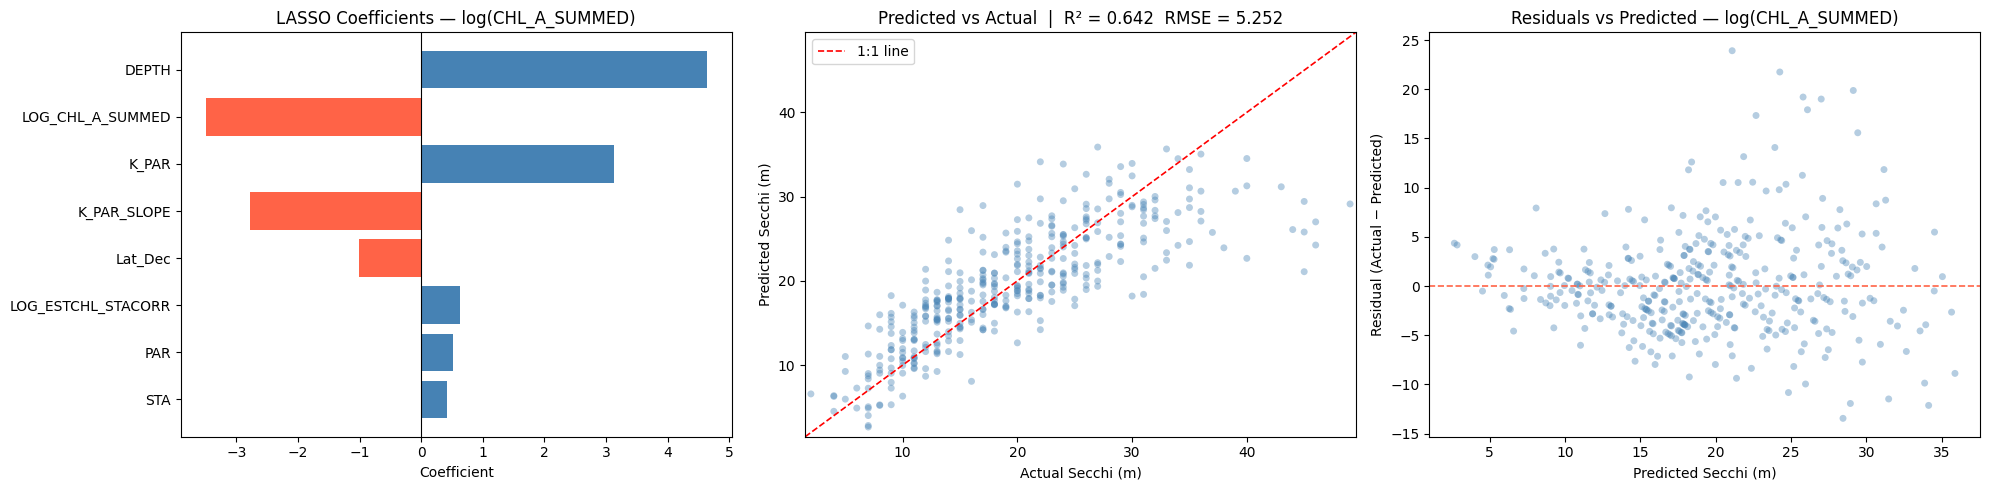

In [48]:
# ── Diagnostics: log-transformed refit ───────────────────────────────────────
residuals_log = y_log_test - y_log_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Coefficient bar chart
ax = axes[0]
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_log_df['Coefficient']]
ax.barh(coef_log_df['Feature'], coef_log_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LASSO Coefficients — log(CHL_A_SUMMED)')
ax.invert_yaxis()

# 2. Predicted vs Actual
ax = axes[1]
lims = [min(y_log_test.min(), y_log_pred.min()) - 0.5,
        max(y_log_test.max(), y_log_pred.max()) + 0.5]
ax.scatter(y_log_test, y_log_pred, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Secchi (m)')
ax.set_ylabel('Predicted Secchi (m)')
ax.set_title(f'Predicted vs Actual  |  R² = {r2_log:.3f}  RMSE = {rmse_log:.3f}')
ax.legend()

# 3. Residuals vs Predicted
ax = axes[2]
ax.scatter(y_log_pred, residuals_log, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.axhline(0, color='tomato', linestyle='--', linewidth=1.2)
ax.set_xlabel('Predicted Secchi (m)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted — log(CHL_A_SUMMED)')

plt.tight_layout()
plt.show()


Model above was refit with logarithmically transformed Chlorophyll variables.

When looking at Kpar values plotted, there are severe outliers 

── K_PAR ────────────────────────────────────────
  count : 1932
  mean  : 0.1020
  std   : 0.0616
  min   : 0.0224
  50th  : 0.0841
  90th  : 0.1810
  95th  : 0.2205
  99th  : 0.3399
  max   : 0.4488
  > 2.0 : 0 rows  (0.0%)

── K_PAR_SLOPE ────────────────────────────────────────
  count : 1932
  mean  : 0.1036
  std   : 0.0765
  min   : 0.0126
  50th  : 0.0797
  90th  : 0.1966
  95th  : 0.2503
  99th  : 0.4169
  max   : 0.4935
  > 2.0 : 0 rows  (0.0%)



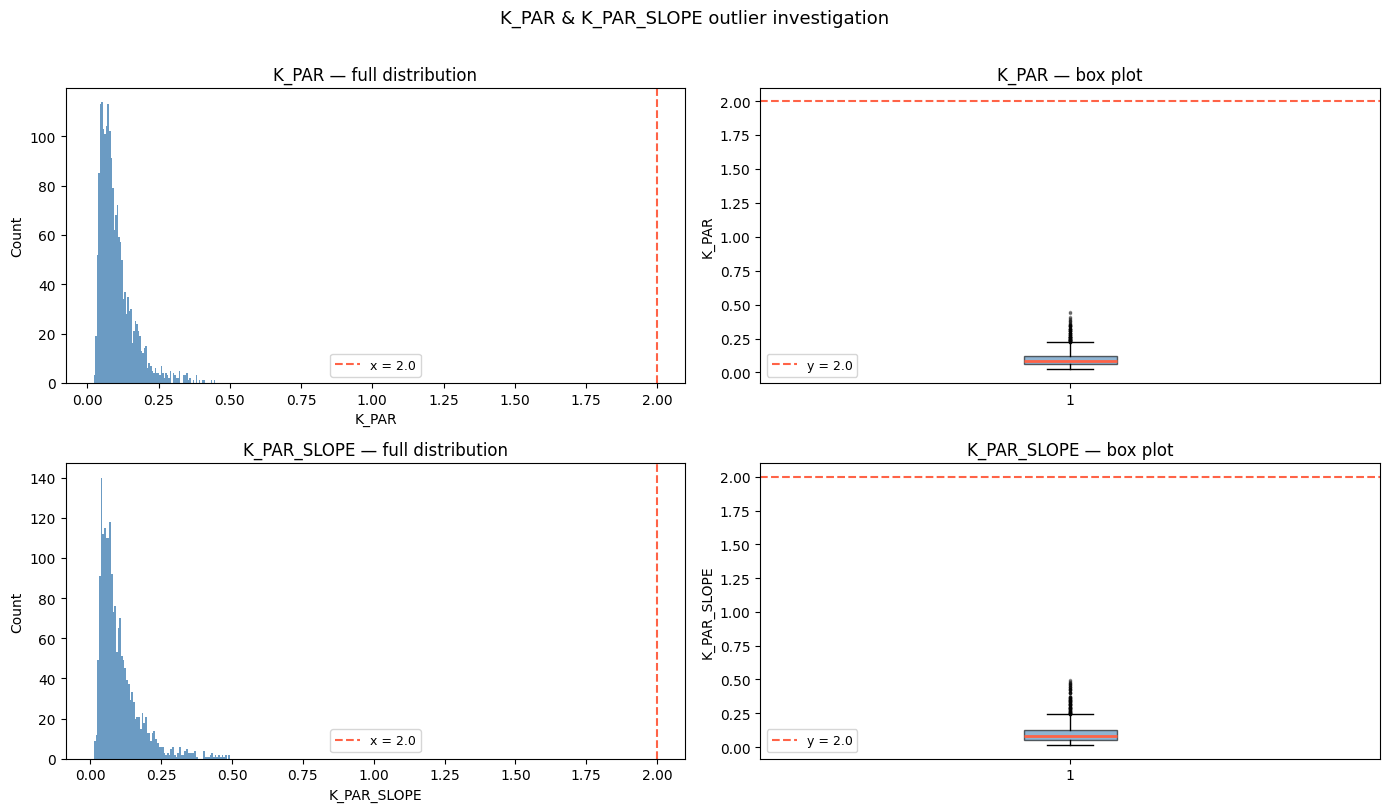

In [49]:
# ── K_PAR / K_PAR_SLOPE distribution diagnostics ────────────────────────────
for col in ['K_PAR', 'K_PAR_SLOPE']:
    s = df_model[col]
    print(f"── {col} ────────────────────────────────────────")
    print(f"  count : {s.count()}")
    print(f"  mean  : {s.mean():.4f}")
    print(f"  std   : {s.std():.4f}")
    print(f"  min   : {s.min():.4f}")
    print(f"  50th  : {s.quantile(0.50):.4f}")
    print(f"  90th  : {s.quantile(0.90):.4f}")
    print(f"  95th  : {s.quantile(0.95):.4f}")
    print(f"  99th  : {s.quantile(0.99):.4f}")
    print(f"  max   : {s.max():.4f}")
    print(f"  > 2.0 : {(s > 2.0).sum()} rows  ({(s > 2.0).mean()*100:.1f}%)")
    print()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, col in enumerate(['K_PAR', 'K_PAR_SLOPE']):
    s = df_model[col]

    # Histogram — full range
    ax = axes[row, 0]
    ax.hist(s, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(2.0, color='tomato', linestyle='--', linewidth=1.5, label='x = 2.0')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} — full distribution')
    ax.legend(fontsize=9)

    # Box plot
    ax = axes[row, 1]
    ax.boxplot(s, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.axhline(2.0, color='tomato', linestyle='--', linewidth=1.5, label='y = 2.0')
    ax.set_ylabel(col)
    ax.set_title(f'{col} — box plot')
    ax.legend(fontsize=9)

plt.suptitle('K_PAR & K_PAR_SLOPE outlier investigation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Log transformed model had R^2 of 0.66

After removing Kpar outliers 3 stds away from the mean (8 rows from K_PAR and 31 from K_PAR_SLOPE), new model R^2 is 0.64. Therefore, we will not filter for these outliers.

---
## LASSO Refit — New_estchlsummed dataset

Same pipeline as above: 3σ K_PAR outlier filter → 80/20 split → LassoCV (5-fold).

In [21]:
# ── Load new dataset ──────────────────────────────────────────────────────────
import pandas as pd
df_new = pd.read_parquet('../Data/Parquet/New_estchlsummed.parquet', engine='pyarrow')
print(df_new.columns)

TARGET_NEW = 'Secchi'
RAW_FEATURES_NEW = ['Lat_Dec', 'STA', 'DEPTH','ESTCHL_SUMMED', 'XMISS_SUMMED','ESTCHL_STACORR', 
                    'K_PAR', 'K_PAR_SLOPE', 'PAR']

df_new_model = df_new[RAW_FEATURES_NEW + [TARGET_NEW]].dropna()
print(f"Rows after dropping NaNs: {len(df_new_model)}")

# ── Log-transform skewed chlorophyll variables ────────────────────────────────
df_new_model = df_new_model.copy()
df_new_model['LOG_ESTCHL_SUMMED']   = np.log1p(df_new_model['ESTCHL_SUMMED'])
df_new_model['LOG_ESTCHL_STACORR'] = np.log1p(df_new_model['ESTCHL_STACORR'])

FEATURES_NEW = ['Lat_Dec', 'STA', 'DEPTH', 'XMISS_SUMMED','LOG_ESTCHL_SUMMED',
                'K_PAR', 'K_PAR_SLOPE', 'PAR', 'LOG_ESTCHL_STACORR']

# ── 80/20 split + standardise ─────────────────────────────────────────────────
X_new = df_new_model[FEATURES_NEW].values
y_new = df_new_model[TARGET_NEW].values

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new, y_new, test_size=0.20, random_state=42
)

scaler_new  = StandardScaler()
X_new_train = scaler_new.fit_transform(X_new_train)
X_new_test  = scaler_new.transform(X_new_test)

# ── LassoCV (5-fold) ──────────────────────────────────────────────────────────
lasso_new = LassoCV(alphas=alphas, cv=kf, max_iter=10_000, random_state=42)
lasso_new.fit(X_new_train, y_new_train)

y_new_pred = lasso_new.predict(X_new_test)
rmse_new   = np.sqrt(mean_squared_error(y_new_test, y_new_pred))
r2_new     = r2_score(y_new_test, y_new_pred)

print(f"\nBest alpha (λ): {lasso_new.alpha_:.6f}")
print(f"\n── Test-set performance ──────────────────────────────")
print(f"  RMSE : {rmse_new:.4f}")
print(f"  R²   : {r2_new:.4f}")

coef_new_df = (
    pd.DataFrame({'Feature': FEATURES_NEW, 'Coefficient': lasso_new.coef_})
    .reindex(pd.Series(np.abs(lasso_new.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n── Feature coefficients (sorted by |coef|) ───────────")
print(coef_new_df.to_string(index=False))

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED',
       'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Cruise_ID',
       'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec',
       'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14',
       'TimeZone', 'Visibility', 'K_PAR', 'K_PAR_SLOPE'],
      dtype='object')
Rows after dropping NaNs: 1963

Best alpha (λ): 0.000100

── Test-set performance ──────────────────────────────
  RMSE : 4.7097
  R²   : 0.6994

── Feature coefficients (sorted by |coef|) ───────────
           Feature  Coefficient
 LOG_ESTCHL_SUMMED    -5.279452
       K_PAR_SLOPE    -3.410918
             K_PAR     3.141776
             DEPTH     2.620801
           Lat_Dec    -0.688785
LOG_ESTCHL_STACORR     

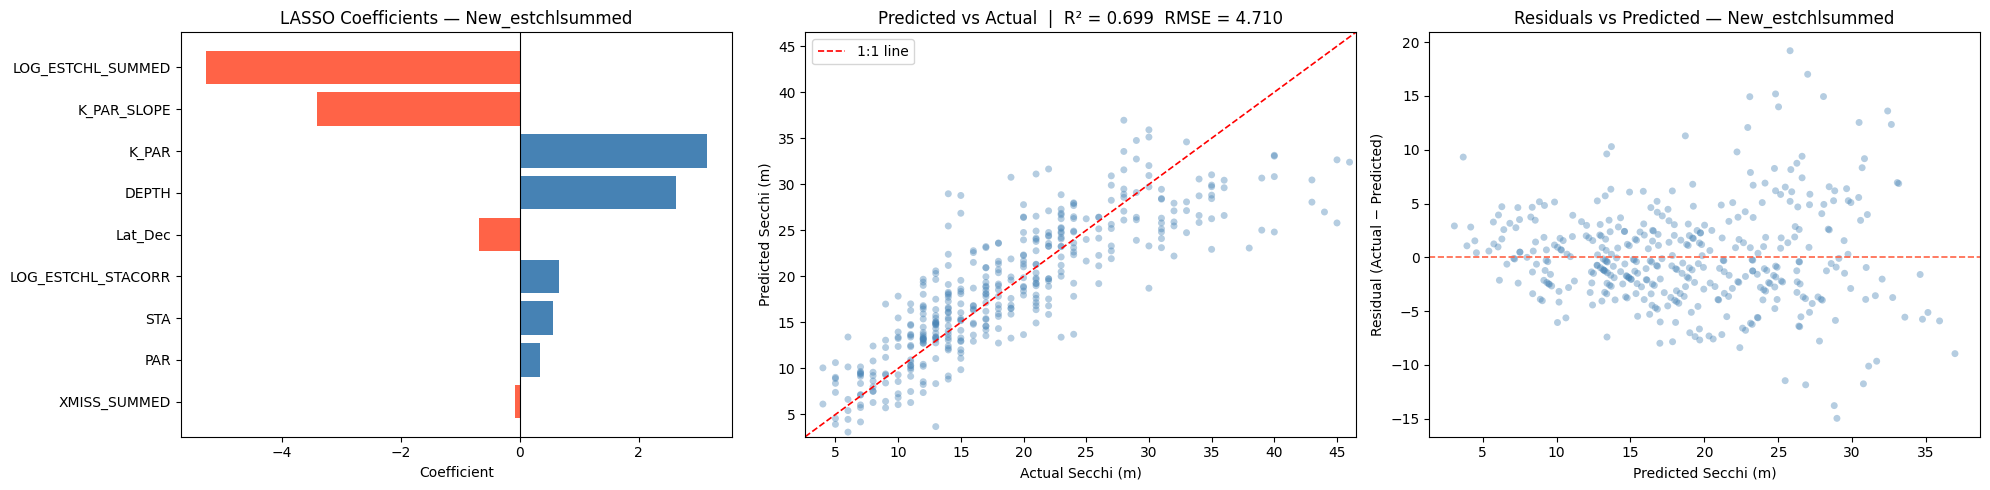

In [22]:
# ── Diagnostics — New_estchlsummed refit ─────────────────────────────────────
residuals_new = y_new_test - y_new_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Coefficient bar chart
ax = axes[0]
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_new_df['Coefficient']]
ax.barh(coef_new_df['Feature'], coef_new_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('LASSO Coefficients — New_estchlsummed')
ax.invert_yaxis()

# 2. Predicted vs Actual
ax = axes[1]
lims = [min(y_new_test.min(), y_new_pred.min()) - 0.5,
        max(y_new_test.max(), y_new_pred.max()) + 0.5]
ax.scatter(y_new_test, y_new_pred, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Secchi (m)')
ax.set_ylabel('Predicted Secchi (m)')
ax.set_title(f'Predicted vs Actual  |  R² = {r2_new:.3f}  RMSE = {rmse_new:.3f}')
ax.legend()

# 3. Residuals vs Predicted
ax = axes[2]
ax.scatter(y_new_pred, residuals_new, alpha=0.4, edgecolors='none', color='steelblue', s=25)
ax.axhline(0, color='tomato', linestyle='--', linewidth=1.2)
ax.set_xlabel('Predicted Secchi (m)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted — New_estchlsummed')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ── Load data ─────────────────────────────────────────────────────────────────
df_poly = pd.read_parquet('../Data/Parquet/New_estchlsummed.parquet', engine='pyarrow')

# ── Define predictors & target ────────────────────────────────────────────────
predictors = ['ESTCHL_SUMMED', 'XMISS_SUMMED', 'K_PAR_SLOPE', 'DEPTH']
TARGET_COL = 'Secchi'

df_poly_model = df_poly[predictors + [TARGET_COL]].copy()
df_poly_model = df_poly_model.dropna()
df_poly_model = df_poly_model[df_poly_model[TARGET_COL] > 0]  # log requires positive values

print(f"Predictors: {predictors}")
print(f"Sample size: {len(df_poly_model)}")

# Check missing values
print(f"\nMissing values:")
for col in predictors:
    missing = df_poly_model[col].isna().sum()
    print(f"  {col}: {missing} ({missing/len(df_poly_model)*100:.1f}%)")

# ── Features & log-transformed target ────────────────────────────────────────
X_p = df_poly_model[predictors].values
y_p = np.log(df_poly_model[TARGET_COL].values)

# ── 80/20 Train / Test split ──────────────────────────────────────────────────
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y_p, test_size=0.20, random_state=42
)

print("\n" + "="*80)
print("POLYNOMIAL REGRESSION (DEGREE 3)")
print("="*80)

# ── Polynomial features ───────────────────────────────────────────────────────
poly = PolynomialFeatures(degree=3, include_bias=False)
X_p_train_poly = poly.fit_transform(X_p_train)
X_p_test_poly  = poly.transform(X_p_test)

poly_feature_names = poly.get_feature_names_out(predictors)

print(f"\nOriginal features: {len(predictors)}")
print(f"Polynomial features: {len(poly_feature_names)}")

# ── Fit & evaluate ────────────────────────────────────────────────────────────
lr_poly = LinearRegression()
lr_poly.fit(X_p_train_poly, y_p_train)

y_p_pred = lr_poly.predict(X_p_test_poly)
r2_poly   = r2_score(y_p_test, y_p_pred)
rmse_poly = np.sqrt(mean_squared_error(y_p_test, y_p_pred))

print(f"\nPolynomial Regression Performance:")
print(f"  R²:   {r2_poly:.4f}")
print(f"  RMSE: {rmse_poly:.4f} m")

# ── Top 10 most important terms ───────────────────────────────────────────────
coef_poly_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': lr_poly.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n\nTop 10 Most Important Terms:")
print(coef_poly_df.head(10).to_string(index=False))

# ── Print simplified equation ─────────────────────────────────────────────────
print("\n" + "="*80)
print("POLYNOMIAL REGRESSION EQUATION FOR SECCHI DEPTH")
print("="*80)
print("log(Secchi) = ", end="")
for i, (coef, feat) in enumerate(zip(lr_poly.coef_, poly_feature_names)):
    if i == 0:
        print(f"{coef:.6f} × {feat}", end="")
    else:
        if coef >= 0:
            print(f"\n             + {coef:.6f} × {feat}", end="")
        else:
            print(f"\n             - {abs(coef):.6f} × {feat}", end="")
print(f"\n             + {lr_poly.intercept_:.6f}")
print(f"\nPerformance:")
print(f"  R²:   {r2_poly:.4f}")
print(f"  RMSE: {rmse_poly:.4f} m")


Predictors: ['ESTCHL_SUMMED', 'XMISS_SUMMED', 'K_PAR', 'DEPTH']
Sample size: 1971

Missing values:
  ESTCHL_SUMMED: 0 (0.0%)
  XMISS_SUMMED: 0 (0.0%)
  K_PAR: 0 (0.0%)
  DEPTH: 0 (0.0%)

POLYNOMIAL REGRESSION (DEGREE 3)

Original features: 4
Polynomial features: 34

Polynomial Regression Performance:
  R²:   0.6287
  RMSE: 0.2909 m


Top 10 Most Important Terms:
                  Feature  Coefficient
                    K_PAR     0.770501
                  K_PAR^2    -0.381778
      ESTCHL_SUMMED K_PAR    -0.132736
                    DEPTH     0.054077
                  K_PAR^3     0.035459
              K_PAR DEPTH    -0.030574
    ESTCHL_SUMMED K_PAR^2     0.021273
            ESTCHL_SUMMED     0.020554
            K_PAR^2 DEPTH     0.016580
ESTCHL_SUMMED K_PAR DEPTH     0.004582

POLYNOMIAL REGRESSION EQUATION FOR SECCHI DEPTH
log(Secchi) = 0.020554 × ESTCHL_SUMMED
             - 0.000700 × XMISS_SUMMED
             + 0.770501 × K_PAR
             + 0.054077 × DEPTH
             - 